In [1]:
import os
import PIL.Image as Image
import matplotlib.pyplot as plt
import numpy as np
import cv2

In [2]:
folder_path = "./images/patatoide/"
folder_path_out = "./images/patatoide_textures/"

In [3]:
def laod_images(folder):
    images = []

    for filename in os.listdir(folder):
        img_path = os.path.join(folder, filename)
        img = Image.open(img_path).convert('RGBA')
        images.append(np.array(img))
    
    return images

def change_R(images, R):
    changed_images = []
    R = np.asarray(R, dtype=np.float32)

    for img in images:
        img_f = img[:, :, :3].astype(np.float32)

        # masque avec alpha
        alpha = img[:, :, 3]
        mask = alpha > 0

        # reshape pour cv2.transform
        h, w, _ = img.shape
        reshaped = img_f.reshape(-1, 1, 3)

        transformed = cv2.transform(reshaped, R)
        transformed = transformed.reshape(h, w, 3)

        img_out = img_f.copy()
        img_out[mask] = np.clip(transformed[mask], 0, 255)

        # remettre le canal alpha
        img_out = np.dstack((img_out, alpha))

        changed_images.append(img_out.astype(np.uint8))

    return changed_images



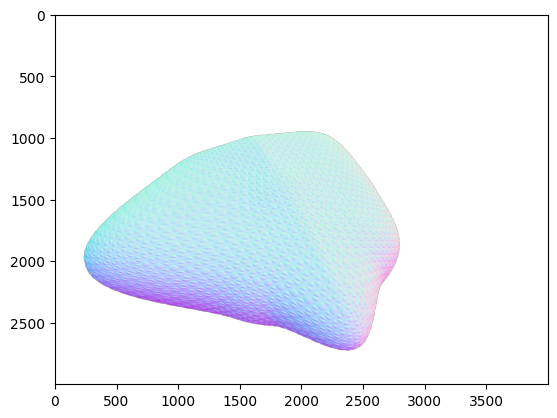

In [4]:
images = laod_images(folder_path)
for img in images[0:1]:
    plt.imshow(img)
    plt.show()

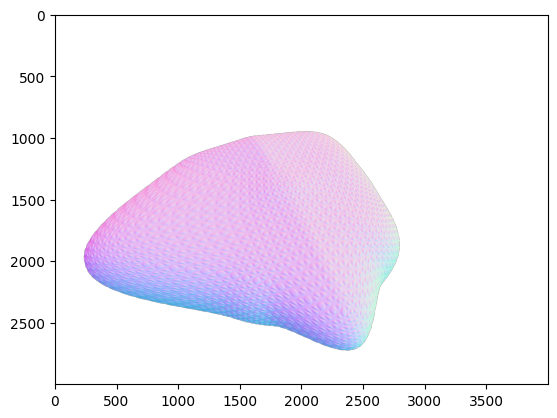

In [5]:
# Matrice de rotation de R360 degrees
R = [[0, 1, 0],
     [1, 0, 0],
     [0, 0, 1]]

changed_images = change_R(images, R)

for img in changed_images[0:1]:
    plt.imshow(img)
    plt.show()

In [6]:
# trouver le min et le max non nul selon x et y
def crop_image(image):
    mask = image[:, :, 3] > 0  # utiliser le canal alpha comme masque
    coords = np.argwhere(mask)

    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0) + 1  # ajouter 1 pour inclure le pixel max
    cropped = image[y0:y1, x0:x1]

    # reshape l'image cropée à une taille standard (par exemple 256x256)
    size = 4096
    cropped = cv2.resize(cropped, (size, size), interpolation=cv2.INTER_AREA)


    return cropped

def crop_images(images):
    cropped_images = []
    for img in images:
        cropped = crop_image(img)
        cropped_images.append(cropped)
    return cropped_images

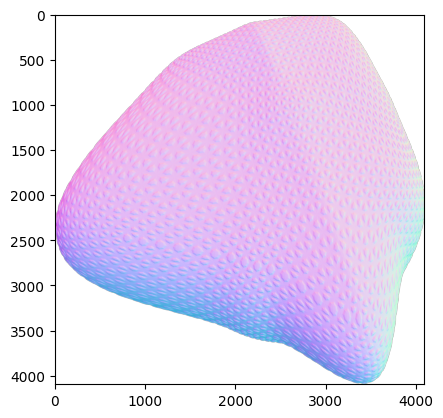

In [7]:
croped_images = crop_images(changed_images)

for img in croped_images[0:1]:
    plt.imshow(img)
    plt.show()

In [8]:
if not os.path.exists(folder_path_out):
    os.makedirs(folder_path_out)

for i, img in enumerate(croped_images):
    img_pil = Image.fromarray(img)
    img_pil.save(os.path.join(folder_path_out, f"texture_{i:03d}.png"))
    